In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from my_nn import activations, loss, metrics, nn
from data.sample_data import generate_data, plot_data

In [2]:
# first get the data
data, targets = generate_data(seed=42)

#### For this notebook we will be looking at the binary classification using the target defined by the parabolic boundary.

In [3]:
# set up X, y for training
# use numpy arrays here for now so train test split works properly
X = np.array(data[["x1","x2"]])
y = np.array(data["binary_parabola"])
data_used = data[["x1","x2","binary_parabola"]].copy()

In [4]:
# do a train_test split
X_train, X_test, y_train, y_test = nn.train_test_split(X, y, test_size = 0.2, random_state=42)

In [5]:
# create 3 versions of the model to train. These will be identical here, and will only differ in how the .fit() is called
model_sgd = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 1, activation="sigmoid")
)

model_momentum = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 1, activation="sigmoid")
)

model_adam = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 1, activation="sigmoid")
)

In [6]:
# train the models
history_sgd = model_sgd.fit(
    X_train,
    y_train,
    epochs=200,
    learning_rate=0.01,
    batch_size=32,
    verbose=False,
    loss_fn="binary_cross_entropy",
    metric="accuracy",
    val_size = 0.2,
    optimizer="sgd"
)

Epoch 1 complete. Average Loss: 0.6447 , accuracy 0.7945 -  Validation Loss: 0.4017, Validation accuracy 0.7831
Epoch 2 complete. Average Loss: 0.3556 , accuracy 0.7997 -  Validation Loss: 0.3554, Validation accuracy 0.7894
Epoch 3 complete. Average Loss: 0.3259 , accuracy 0.8219 -  Validation Loss: 0.3352, Validation accuracy 0.8113
Epoch 4 complete. Average Loss: 0.3091 , accuracy 0.8508 -  Validation Loss: 0.3222, Validation accuracy 0.8306
Epoch 5 complete. Average Loss: 0.2975 , accuracy 0.8697 -  Validation Loss: 0.3130, Validation accuracy 0.8512
Epoch 6 complete. Average Loss: 0.2887 , accuracy 0.8823 -  Validation Loss: 0.3060, Validation accuracy 0.8688
Epoch 7 complete. Average Loss: 0.2816 , accuracy 0.8922 -  Validation Loss: 0.3000, Validation accuracy 0.8831
Epoch 8 complete. Average Loss: 0.2756 , accuracy 0.8989 -  Validation Loss: 0.2946, Validation accuracy 0.8956
Epoch 9 complete. Average Loss: 0.2704 , accuracy 0.9033 -  Validation Loss: 0.2899, Validation accuracy

In [7]:
history_momentum = model_momentum.fit(
    X_train,
    y_train,
    epochs=200,
    learning_rate=0.01,
    batch_size=32,
    verbose=False,
    loss_fn="binary_cross_entropy",
    metric="accuracy",
    val_size = 0.2,
    optimizer="momentum"
)

Epoch 1 complete. Average Loss: 0.5389 , accuracy 0.9008 -  Validation Loss: 0.3499, Validation accuracy 0.8950
Epoch 2 complete. Average Loss: 0.3260 , accuracy 0.8920 -  Validation Loss: 0.3023, Validation accuracy 0.8938
Epoch 3 complete. Average Loss: 0.2950 , accuracy 0.8973 -  Validation Loss: 0.2785, Validation accuracy 0.9012
Epoch 4 complete. Average Loss: 0.2746 , accuracy 0.9005 -  Validation Loss: 0.2616, Validation accuracy 0.9025
Epoch 5 complete. Average Loss: 0.2594 , accuracy 0.9020 -  Validation Loss: 0.2488, Validation accuracy 0.9012
Epoch 6 complete. Average Loss: 0.2476 , accuracy 0.9025 -  Validation Loss: 0.2389, Validation accuracy 0.9012
Epoch 7 complete. Average Loss: 0.2382 , accuracy 0.9030 -  Validation Loss: 0.2311, Validation accuracy 0.8994
Epoch 8 complete. Average Loss: 0.2306 , accuracy 0.9030 -  Validation Loss: 0.2248, Validation accuracy 0.8981
Epoch 9 complete. Average Loss: 0.2244 , accuracy 0.9030 -  Validation Loss: 0.2195, Validation accuracy

In [8]:
history_adam = model_adam.fit(
    X_train,
    y_train,
    epochs=200,
    learning_rate=0.01,
    batch_size=32,
    verbose=False,
    loss_fn="binary_cross_entropy",
    metric="accuracy",
    val_size = 0.2,
    optimizer="adam"
)

Epoch 1 complete. Average Loss: 0.1159 , accuracy 0.9827 -  Validation Loss: 0.0409, Validation accuracy 0.9788
Epoch 2 complete. Average Loss: 0.0468 , accuracy 0.9886 -  Validation Loss: 0.0291, Validation accuracy 0.9856
Epoch 3 complete. Average Loss: 0.0392 , accuracy 0.9906 -  Validation Loss: 0.0322, Validation accuracy 0.9900
Epoch 4 complete. Average Loss: 0.0302 , accuracy 0.9917 -  Validation Loss: 0.0211, Validation accuracy 0.9888
Epoch 5 complete. Average Loss: 0.0262 , accuracy 0.9928 -  Validation Loss: 0.0189, Validation accuracy 0.9906
Epoch 6 complete. Average Loss: 0.0278 , accuracy 0.9881 -  Validation Loss: 0.0289, Validation accuracy 0.9869
Epoch 7 complete. Average Loss: 0.0262 , accuracy 0.9841 -  Validation Loss: 0.0401, Validation accuracy 0.9825
Epoch 8 complete. Average Loss: 0.0201 , accuracy 0.9948 -  Validation Loss: 0.0114, Validation accuracy 0.9969
Epoch 9 complete. Average Loss: 0.0196 , accuracy 0.9953 -  Validation Loss: 0.0185, Validation accuracy

c:\Users\ronsp\IdeaProjects\neural_networks\my_nn\activations.py:28: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


Epoch 176 complete. Average Loss: 0.0079 , accuracy 0.9981 -  Validation Loss: 0.0071, Validation accuracy 0.9962
Epoch 177 complete. Average Loss: 0.0085 , accuracy 0.9988 -  Validation Loss: 0.0069, Validation accuracy 0.9975
Epoch 178 complete. Average Loss: 0.0073 , accuracy 0.9952 -  Validation Loss: 0.0165, Validation accuracy 0.9931
Epoch 179 complete. Average Loss: 0.0113 , accuracy 0.9981 -  Validation Loss: 0.0060, Validation accuracy 0.9981
Epoch 180 complete. Average Loss: 0.0104 , accuracy 0.9981 -  Validation Loss: 0.0095, Validation accuracy 0.9962
Epoch 181 complete. Average Loss: 0.0088 , accuracy 0.9969 -  Validation Loss: 0.0057, Validation accuracy 0.9981
Epoch 182 complete. Average Loss: 0.0095 , accuracy 0.9939 -  Validation Loss: 0.0169, Validation accuracy 0.9931
Epoch 183 complete. Average Loss: 0.0096 , accuracy 0.9977 -  Validation Loss: 0.0107, Validation accuracy 0.9944
Epoch 184 complete. Average Loss: 0.0103 , accuracy 0.9991 -  Validation Loss: 0.0059, V

#### Let's look at the histories of each

##### First for standard gradient descent

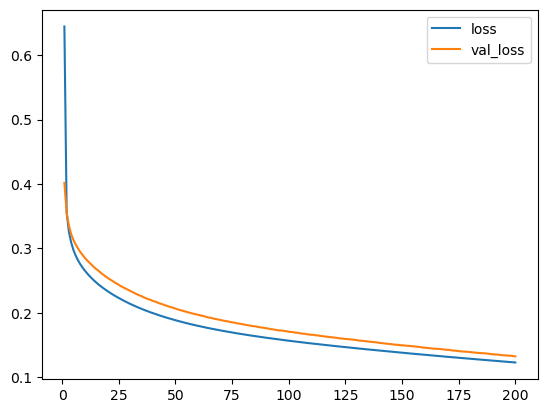

In [9]:
nn.plot_history(history_sgd, "loss", "val_loss")

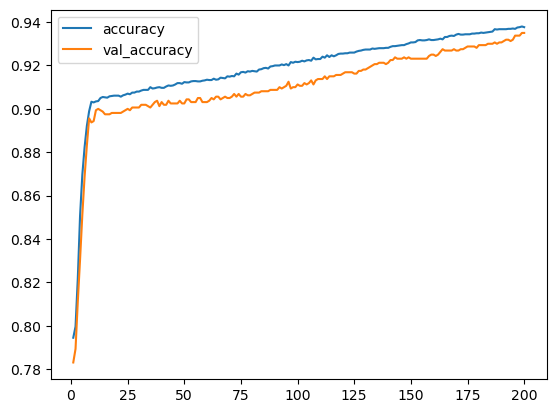

In [10]:
nn.plot_history(history_sgd, "accuracy", "val_accuracy")

##### Next for momentum

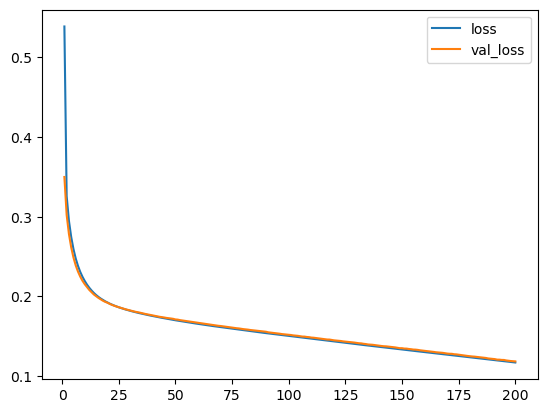

In [11]:
nn.plot_history(history_momentum, "loss", "val_loss")

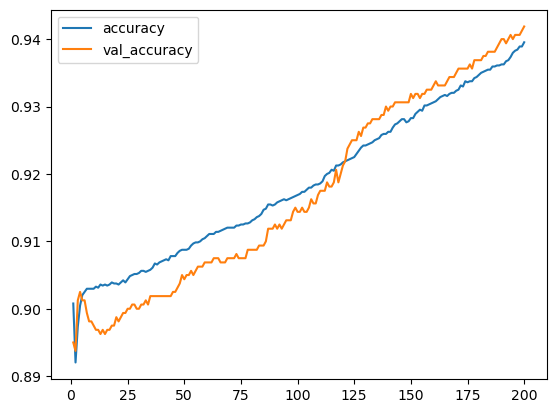

In [12]:
nn.plot_history(history_momentum, "accuracy", "val_accuracy")

In [13]:
##### Finally for adam

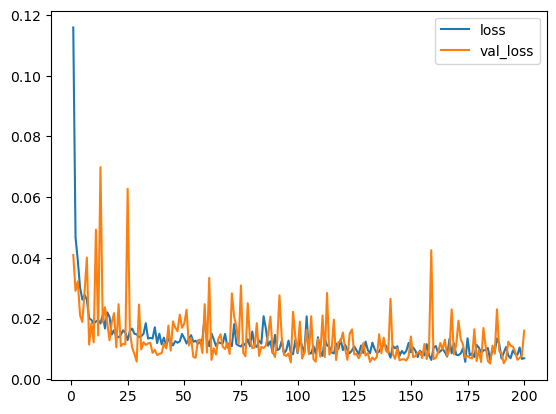

In [14]:
nn.plot_history(history_adam, "loss", "val_loss")

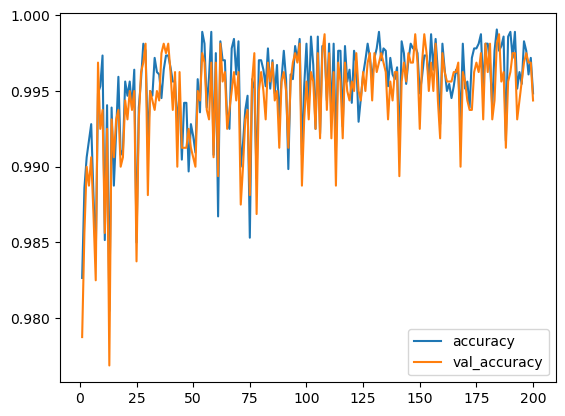

In [15]:
nn.plot_history(history_adam, "accuracy", "val_accuracy")

#### Now lets see how these do on the unseen test data

In [16]:
y_pred_sgd = model_sgd.predict(X_test)
y_pred_momentum = model_momentum.predict(X_test)
y_pred_adam = model_adam.predict(X_test)

In [17]:
print("SGD all real numbers: ", np.isfinite(y_pred_sgd).all())
print("Momentum all real numbers: ",np.isfinite(y_pred_momentum).all())
print("Adam all real numbers: ", np.isfinite(y_pred_adam).all())

SGD all real numbers:  True
Momentum all real numbers:  True
Adam all real numbers:  True


In [18]:
# convert to 0,1 for use in metrics
y_labels_sgd = (y_pred_sgd >= 0.5).astype(int)
y_labels_momentum = (y_pred_momentum>=0.5).astype(int)
y_labels_adam = (y_pred_adam>=0.5).astype(int)

In [19]:
acc_sgd = metrics.accuracy(y_test, y_labels_sgd)
acc_mom = metrics.accuracy(y_test, y_labels_momentum)
acc_adam = metrics.accuracy(y_test, y_labels_adam)

precision_sgd = metrics.precision(y_test, y_labels_sgd)
precision_mom = metrics.precision(y_test, y_labels_momentum)
precision_adam = metrics.precision(y_test, y_labels_adam)

recall_sgd = metrics.recall(y_test, y_labels_sgd)
recall_mom = metrics.recall(y_test, y_labels_momentum)
recall_adam = metrics.recall(y_test, y_labels_adam)

f1_sgd = metrics.f1_score(y_test, y_labels_sgd)
f1_mom = metrics.f1_score(y_test, y_labels_momentum)
f1_adam = metrics.f1_score(y_test, y_labels_adam)

spec_sgd = metrics.specificity(y_test, y_labels_sgd)
spec_mom = metrics.specificity(y_test, y_labels_momentum)
spec_adam = metrics.specificity(y_test, y_labels_adam)

bal_acc_sgd = metrics.balanced_accuracy(y_test, y_labels_sgd)
bal_acc_mom = metrics.balanced_accuracy(y_test, y_labels_momentum)
bal_acc_adam = metrics.balanced_accuracy(y_test, y_labels_adam)

In [20]:
print("For Standard Gradient Descent")
print("-----------------------------")
print(f"Accuracy: {acc_sgd: .4f}")
print(f"Precision: {precision_sgd: .4f}")
print(f"Recall: {recall_sgd: .4f}")
print(f"F1 Score: {f1_sgd: .4f}")
print(f"Specificity: {spec_sgd: .4f}")
print(f"Balanced Accuracy: {bal_acc_sgd: .4f}")

For Standard Gradient Descent
-----------------------------
Accuracy:  0.9390
Precision:  0.7894
Recall:  0.9639
F1 Score:  0.8680
Specificity:  0.9324
Balanced Accuracy:  0.9482


In [21]:
print("For using momentum")
print("-----------------------------")
print(f"Accuracy: {acc_mom: .4f}")
print(f"Precision: {precision_mom: .4f}")
print(f"Recall: {recall_mom: .4f}")
print(f"F1 Score: {f1_mom: .4f}")
print(f"Specificity: {spec_mom: .4f}")
print(f"Balanced Accuracy: {bal_acc_mom: .4f}")

For using momentum
-----------------------------
Accuracy:  0.9420
Precision:  0.7972
Recall:  0.9689
F1 Score:  0.8747
Specificity:  0.9349
Balanced Accuracy:  0.9519


In [22]:
print("For Adam optimization")
print("-----------------------------")
print(f"Accuracy: {acc_adam: .4f}")
print(f"Precision: {precision_adam: .4f}")
print(f"Recall: {recall_adam: .4f}")
print(f"F1 Score: {f1_adam: .4f}")
print(f"Specificity: {spec_adam: .4f}")
print(f"Balanced Accuracy: {bal_acc_adam: .4f}")

For Adam optimization
-----------------------------
Accuracy:  0.9930
Precision:  0.9783
Recall:  0.9940
F1 Score:  0.9861
Specificity:  0.9927
Balanced Accuracy:  0.9933


#### Lastly we look at visualizing how the model does on the whole space for each version. All will show the true decision boundary and scatterplot the points, coloring by prediction.

In [23]:
y_pred_sgd = (model_sgd.predict(X) >= 0.5).astype(int)
y_pred_mom = (model_momentum.predict(X) >= 0.5).astype(int)
y_pred_adam = (model_adam.predict(X) >= 0.5).astype(int)

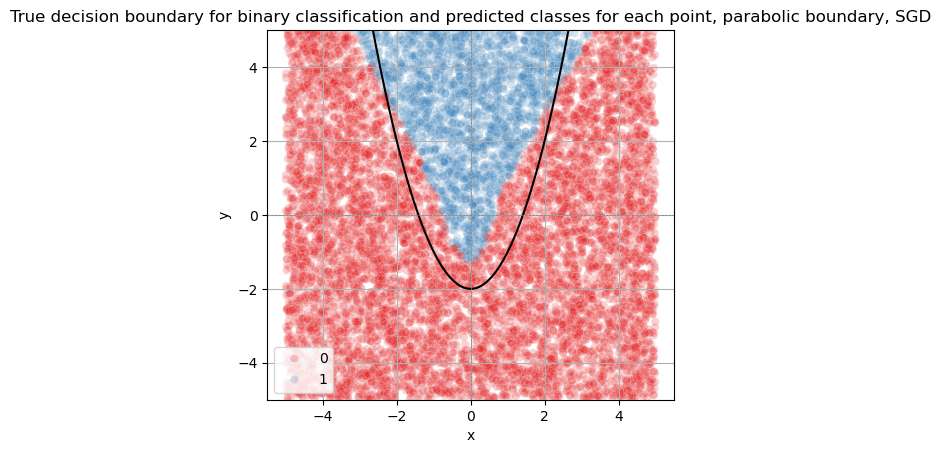

In [26]:
x = np.linspace(-5, 5, 400)
y = x**2 - 2
plt.plot(x, y, color='k', linestyle='solid')
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y_pred_sgd.ravel(), palette='Set1', alpha=0.2)

# Add labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title("True decision boundary for binary classification and predicted classes for each point, parabolic boundary, SGD")
plt.grid(True)
plt.ylim(-5,5)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='box') # Ensure proper aspect ratio
plt.show()

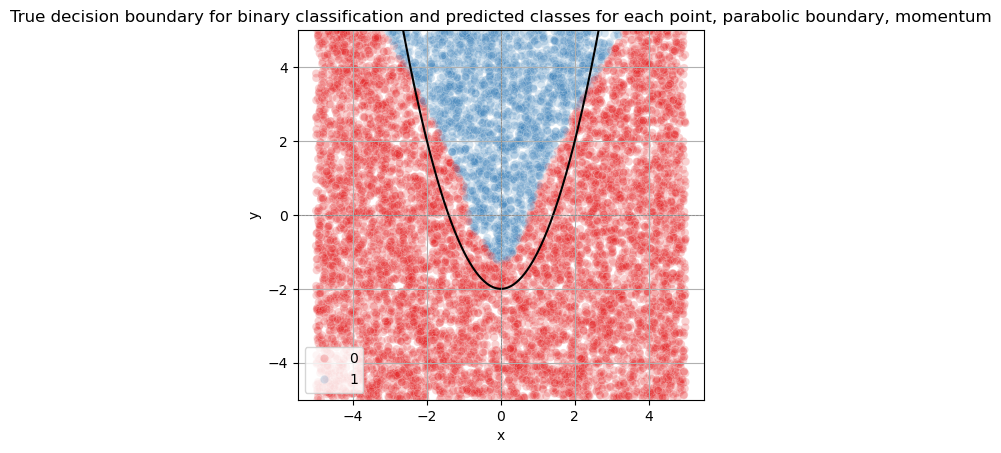

In [27]:
x = np.linspace(-5, 5, 400)
y = x**2 - 2
plt.plot(x, y, color='k', linestyle='solid')
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y_pred_mom.ravel(), palette='Set1', alpha=0.2)

# Add labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title("True decision boundary for binary classification and predicted classes for each point, parabolic boundary, momentum")
plt.grid(True)
plt.ylim(-5,5)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='box') # Ensure proper aspect ratio
plt.show()

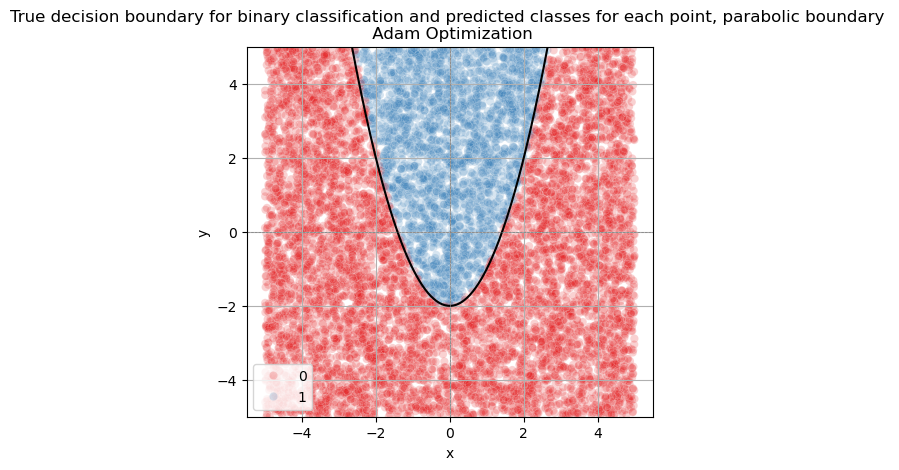

In [28]:
x = np.linspace(-5, 5, 400)
y = x**2 - 2
plt.plot(x, y, color='k', linestyle='solid')
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y_pred_adam.ravel(), palette='Set1', alpha=0.2)

# Add labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title("True decision boundary for binary classification and predicted classes for each point, parabolic boundary \n Adam Optimization")
plt.grid(True)
plt.ylim(-5,5)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='box') # Ensure proper aspect ratio
plt.show()